## 2. Install Required Libraries

In [ ]:

!pip install transformers timm -q

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3. Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import cv2
import os
import pickle
from imutils import paths
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# For Swin Transformer
import timm
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image

print(f"TensorFlow version: {tf.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"GPU Available: {torch.cuda.is_available()}")

%matplotlib inline

TensorFlow version: 2.19.0
PyTorch version: 2.9.0+cu126
GPU Available: True


## 4. Configuration

In [ ]:
# Configuration
class Config:
    # Paths
    BASE_PATH = '/content/drive/MyDrive/My_Saved_Folder/Wheat-Disease-Detection--main/Images/'  # Update this path as needed
    MODEL_SAVE_PATH = '/content/drive/MyDrive/My_Saved_Folder/Wheat-Disease-Detection--main/NewResults/'

    # Image settings
    IMG_SIZE = 224
    CHANNELS = 3

    # Training settings
    BATCH_SIZE = 32
    EPOCHS = 50
    LEARNING_RATE = 1e-4
    WEIGHT_DECAY = 1e-5

    # Classes
    CLASSES = ['Crown and Root Rot', 'Healthy Wheat', 'Leaf Rust', 'Wheat Loose Smut']
    NUM_CLASSES = 4

    # Model settings
    SWIN_MODEL = 'swin_tiny_patch4_window7_224'  # Options: swin_tiny, swin_small, swin_base
    PRETRAINED = True

    # Device
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

config = Config()
print(f"Using device: {config.DEVICE}")

Using device: cuda


## 5. Data Loading and Preprocessing

In [ ]:
def load_dataset(base_path, img_size=224):
    """Load images and labels from the dataset directory."""
    images = []
    labels = []
    image_paths = []

    class_folders = [
        'Crown and Root Rot',
        'Healthy Wheat',
        'Leaf Rust',
        'Wheat Loose Smut'
    ]

    for class_name in class_folders:
        class_path = os.path.join(base_path, class_name)
        if not os.path.exists(class_path):
            print(f"Warning: {class_path} does not exist")
            continue

        print(f"Loading images from: {class_name}")

        for img_name in tqdm(os.listdir(class_path)):
            img_path = os.path.join(class_path, img_name)
            try:
                img = cv2.imread(img_path)
                if img is None:
                    continue
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (img_size, img_size))

                images.append(img)
                labels.append(class_name)
                image_paths.append(img_path)
            except Exception as e:
                print(f"Error loading {img_path}: {e}")
                continue

    images = np.array(images)
    labels = np.array(labels)

    print(f"\nTotal images loaded: {len(images)}")
    print(f"Image shape: {images[0].shape}")

    return images, labels, image_paths

# Load the dataset
images, labels, image_paths = load_dataset(config.BASE_PATH, config.IMG_SIZE)

Loading images from: Crown and Root Rot


100%|██████████| 1033/1033 [00:33<00:00, 31.30it/s]


Loading images from: Healthy Wheat


100%|██████████| 1280/1280 [02:17<00:00,  9.31it/s]


Loading images from: Leaf Rust


100%|██████████| 1622/1622 [03:49<00:00,  7.05it/s]


Loading images from: Wheat Loose Smut


100%|██████████| 939/939 [00:42<00:00, 22.23it/s] 



Total images loaded: 4874
Image shape: (224, 224, 3)


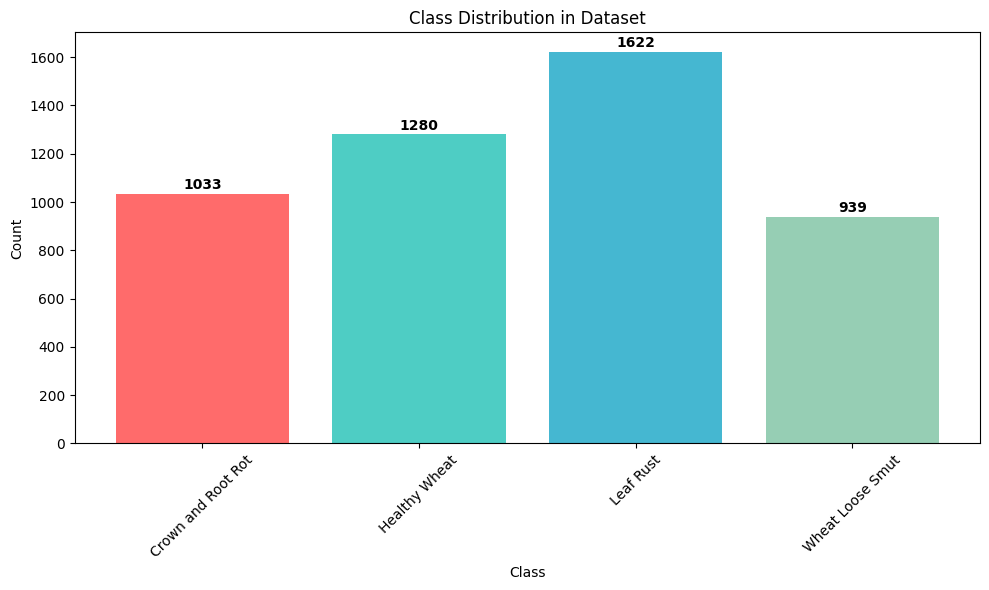

In [ ]:
# Visualize class distribution
unique, counts = np.unique(labels, return_counts=True)
plt.figure(figsize=(10, 6))
plt.bar(unique, counts, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Class Distribution in Dataset')
plt.xticks(rotation=45)
for i, (u, c) in enumerate(zip(unique, counts)):
    plt.text(i, c + 20, str(c), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

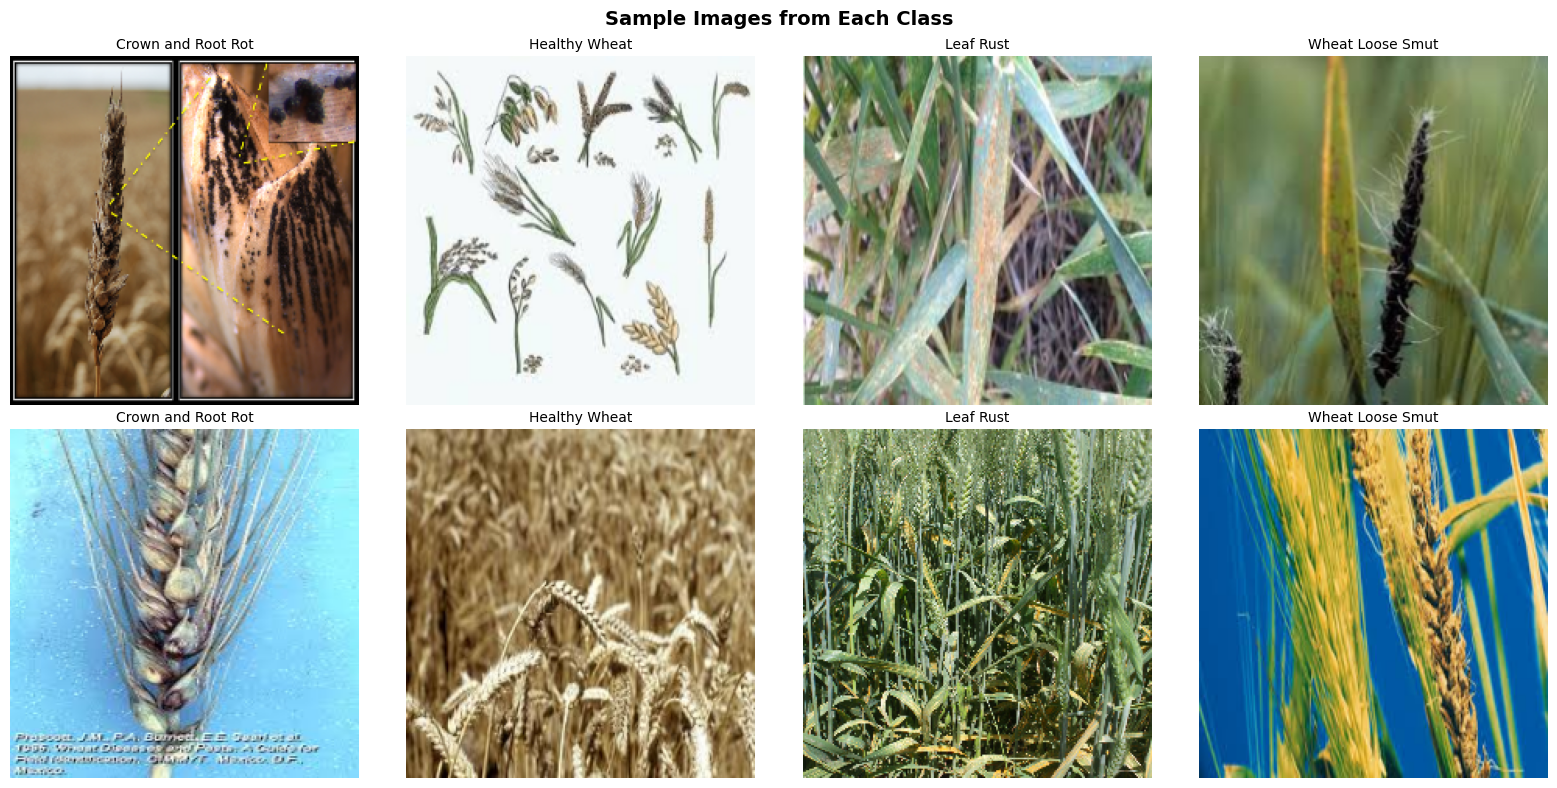

In [ ]:
# Visualize sample images from each class
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, class_name in enumerate(config.CLASSES):
    class_indices = np.where(labels == class_name)[0]
    sample_indices = np.random.choice(class_indices, 2, replace=False)

    for j, idx in enumerate(sample_indices):
        ax = axes[j, i]
        ax.imshow(images[idx])
        ax.set_title(class_name, fontsize=10)
        ax.axis('off')

plt.suptitle('Sample Images from Each Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Data Preparation for PyTorch

In [ ]:
# Encode labels
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(labels)

print("Label mapping:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"  {i}: {class_name}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    images, encoded_labels,
    test_size=0.2,
    stratify=encoded_labels,
    random_state=42
)

print(f"\nTraining set: {len(X_train)} images")
print(f"Test set: {len(X_test)} images")

Label mapping:
  0: Crown and Root Rot
  1: Healthy Wheat
  2: Leaf Rust
  3: Wheat Loose Smut

Training set: 3899 images
Test set: 975 images


In [ ]:
# Custom Dataset class for PyTorch
class WheatDiseaseDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]

        # Convert to PIL Image for transforms
        image = Image.fromarray(image.astype('uint8'))

        if self.transform:
            image = self.transform(image)

        return image, label

# Data augmentation and normalization
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create datasets
train_dataset = WheatDiseaseDataset(X_train, y_train, transform=train_transform)
test_dataset = WheatDiseaseDataset(X_test, y_test, transform=test_transform)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 122
Test batches: 31


## 7. Hybrid CNN + Swin Transformer Model

### Architecture:
1. **CNN Feature Extractor**: First few layers of ResNet50 to extract local features
2. **Swin Transformer**: For global context and attention-based feature learning
3. **Classification Head**: Dense layers for final prediction

In [ ]:
class HybridCNNSwinTransformer(nn.Module):
    """
    Hybrid CNN + Swin Transformer model for image classification.

    Architecture:
    - CNN backbone (ResNet50 early layers) for local feature extraction
    - Swin Transformer for global context modeling
    - Fusion layer to combine both representations
    - Classification head
    """

    def __init__(self, num_classes=4, pretrained=True, cnn_backbone='resnet50'):
        super(HybridCNNSwinTransformer, self).__init__()

        # CNN Backbone (ResNet50 - first 3 stages)
        resnet = timm.create_model('resnet50', pretrained=pretrained)
        self.cnn_features = nn.Sequential(
            resnet.conv1,
            resnet.bn1,
            resnet.act1,
            resnet.maxpool,
            resnet.layer1,
            resnet.layer2,
        )
        self.cnn_out_channels = 512  # Output channels after layer2

        # Projection layer to match Swin input
        self.cnn_projection = nn.Sequential(
            nn.Conv2d(self.cnn_out_channels, 96, kernel_size=1),
            nn.BatchNorm2d(96),
            nn.GELU()
        )

        # Swin Transformer
        self.swin = timm.create_model(
            'swin_tiny_patch4_window7_224',
            pretrained=pretrained,
            num_classes=0  # Remove classification head
        )
        self.swin_out_features = self.swin.num_features  # 768 for swin_tiny

        # CNN Global Average Pooling
        self.cnn_gap = nn.AdaptiveAvgPool2d(1)

        # Fusion layer
        self.fusion = nn.Sequential(
            nn.Linear(self.cnn_out_channels + self.swin_out_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        # Classification head
        self.classifier = nn.Linear(256, num_classes)

    def forward(self, x):
        # CNN branch
        cnn_features = self.cnn_features(x)
        cnn_pooled = self.cnn_gap(cnn_features)
        cnn_pooled = cnn_pooled.view(cnn_pooled.size(0), -1)

        # Swin Transformer branch
        swin_features = self.swin(x)

        # Fusion
        combined = torch.cat([cnn_pooled, swin_features], dim=1)
        fused = self.fusion(combined)

        # Classification
        output = self.classifier(fused)

        return output

# Create model
model = HybridCNNSwinTransformer(num_classes=config.NUM_CLASSES, pretrained=config.PRETRAINED)
model = model.to(config.DEVICE)

# Print model summary
print("Hybrid CNN + Swin Transformer Model")
print("=" * 50)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Hybrid CNN + Swin Transformer Model
Total parameters: 29,801,950
Trainable parameters: 29,801,950


## 8. Alternative: Pure Swin Transformer Model

In [ ]:
class SwinTransformerClassifier(nn.Module):
    """
    Pure Swin Transformer for image classification.
    Uses pretrained Swin Transformer with custom classification head.
    """

    def __init__(self, num_classes=4, model_name='swin_tiny_patch4_window7_224', pretrained=True):
        super(SwinTransformerClassifier, self).__init__()

        # Load pretrained Swin Transformer
        self.swin = timm.create_model(
            model_name,
            pretrained=pretrained,
            num_classes=num_classes
        )

    def forward(self, x):
        return self.swin(x)

# Create pure Swin model for comparison
swin_model = SwinTransformerClassifier(num_classes=config.NUM_CLASSES)
swin_model = swin_model.to(config.DEVICE)

print("Pure Swin Transformer Model")
print("=" * 50)
total_params = sum(p.numel() for p in swin_model.parameters())
print(f"Total parameters: {total_params:,}")

Pure Swin Transformer Model
Total parameters: 27,522,430


## 9. Training Functions

In [ ]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(dataloader, desc='Training')
    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{100*correct/total:.2f}%'})

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc


def validate(model, dataloader, criterion, device):
    """Validate the model."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc='Validation'):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc, all_preds, all_labels

In [ ]:
def train_model(model, train_loader, test_loader, config, model_name='hybrid_cnn_swin'):
    """Full training loop."""

    # Loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config.LEARNING_RATE,
        weight_decay=config.WEIGHT_DECAY
    )

    # Learning rate scheduler
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=config.EPOCHS,
        eta_min=1e-6
    )

    # Training history
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }

    best_acc = 0.0

    for epoch in range(config.EPOCHS):
        print(f"\nEpoch {epoch+1}/{config.EPOCHS}")
        print("-" * 40)

        # Training
        train_loss, train_acc = train_epoch(
            model, train_loader, criterion, optimizer, config.DEVICE
        )

        # Validation
        val_loss, val_acc, _, _ = validate(
            model, test_loader, criterion, config.DEVICE
        )

        # Update scheduler
        scheduler.step()

        # Save history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

        # Save best model
        if val_acc > best_acc:
            best_acc = val_acc
            os.makedirs(config.MODEL_SAVE_PATH, exist_ok=True)
            torch.save(model.state_dict(), f'{config.MODEL_SAVE_PATH}/{model_name}_best.pth')
            print(f"Saved best model with accuracy: {best_acc:.2f}%")

    print(f"\nTraining completed. Best validation accuracy: {best_acc:.2f}%")

    return history

## 10. Train Hybrid CNN + Swin Transformer

In [ ]:
# Train the hybrid model
print("Training Hybrid CNN + Swin Transformer Model")
print("=" * 60)

hybrid_history = train_model(
    model,
    train_loader,
    test_loader,
    config,
    model_name='hybrid_cnn_swin_wheat'
)

Training Hybrid CNN + Swin Transformer Model

Epoch 1/50
----------------------------------------


Validation: 100%|██████████| 31/31 [00:06<00:00,  4.99it/s]


Train Loss: 0.6482, Train Acc: 77.53%
Val Loss: 0.4479, Val Acc: 86.05%
Saved best model with accuracy: 86.05%

Epoch 2/50
----------------------------------------


Validation: 100%|██████████| 31/31 [00:06<00:00,  4.89it/s]


Train Loss: 0.3889, Train Acc: 87.12%
Val Loss: 0.3974, Val Acc: 87.18%
Saved best model with accuracy: 87.18%

Epoch 3/50
----------------------------------------


...

Train Loss: 0.0161, Train Acc: 99.20%
Val Loss: 0.2679, Val Acc: 95.59%

Epoch 49/50
----------------------------------------


Validation: 100%|██████████| 31/31 [00:06<00:00,  4.85it/s]


Train Loss: 0.0154, Train Acc: 99.18%
Val Loss: 0.2681, Val Acc: 95.59%

Epoch 50/50
----------------------------------------


Validation: 100%|██████████| 31/31 [00:06<00:00,  4.79it/s]

Train Loss: 0.0159, Train Acc: 99.18%
Val Loss: 0.2704, Val Acc: 95.59%

Training completed. Best validation accuracy: 96.21%


## 11. Training Visualization

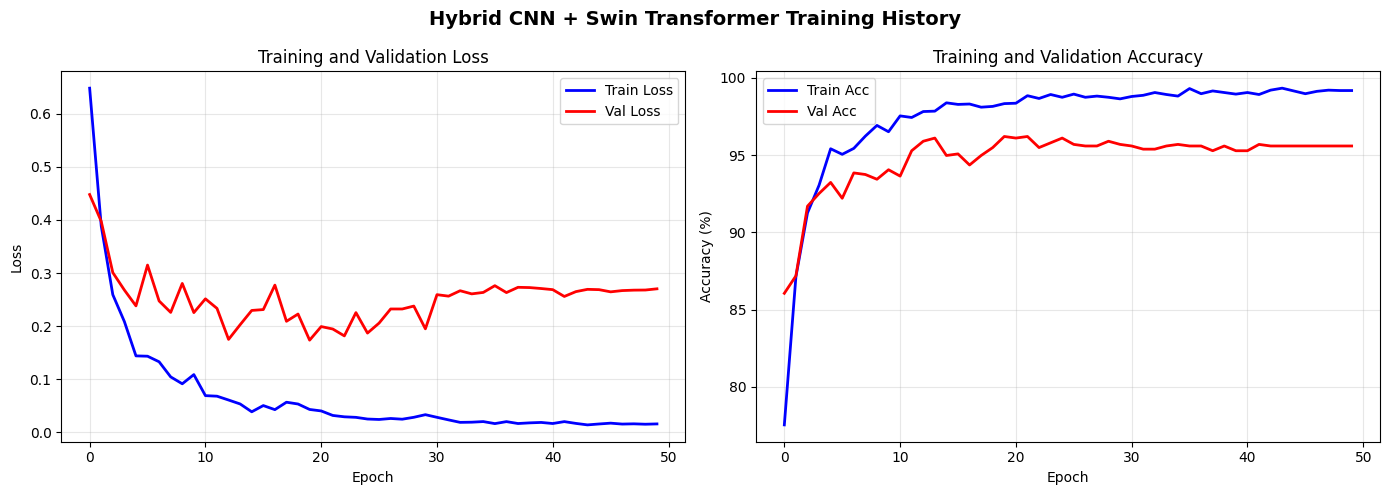

In [ ]:
def plot_training_history(history, title='Training History'):
    """Plot training and validation metrics."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss plot
    axes[0].plot(history['train_loss'], label='Train Loss', color='blue', linewidth=2)
    axes[0].plot(history['val_loss'], label='Val Loss', color='red', linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy plot
    axes[1].plot(history['train_acc'], label='Train Acc', color='blue', linewidth=2)
    axes[1].plot(history['val_acc'], label='Val Acc', color='red', linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title('Training and Validation Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/My_Saved_Folder/Wheat-Disease-Detection--main/NewResults/Plots/hybrid_cnn_swin_training_history.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_training_history(hybrid_history, 'Hybrid CNN + Swin Transformer Training History')

## 12. Model Evaluation

In [ ]:
# Load best model and evaluate
model.load_state_dict(torch.load(f'{config.MODEL_SAVE_PATH}/hybrid_cnn_swin_wheat_best.pth'))

criterion = nn.CrossEntropyLoss()
val_loss, val_acc, all_preds, all_labels = validate(model, test_loader, criterion, config.DEVICE)

print(f"\nFinal Test Results:")
print(f"Loss: {val_loss:.4f}")
print(f"Accuracy: {val_acc:.2f}%")

Validation: 100%|██████████| 31/31 [00:06<00:00,  4.78it/s]


Final Test Results:
Loss: 0.1737
Accuracy: 96.21%


In [ ]:
# Classification Report
print("\nClassification Report:")
print("=" * 60)
print(classification_report(all_labels, all_preds, target_names=config.CLASSES))


Classification Report:
                    precision    recall  f1-score   support

Crown and Root Rot       0.93      0.99      0.96       207
     Healthy Wheat       0.97      0.94      0.95       256
         Leaf Rust       0.98      0.98      0.98       324
  Wheat Loose Smut       0.96      0.94      0.95       188

          accuracy                           0.96       975
         macro avg       0.96      0.96      0.96       975
      weighted avg       0.96      0.96      0.96       975



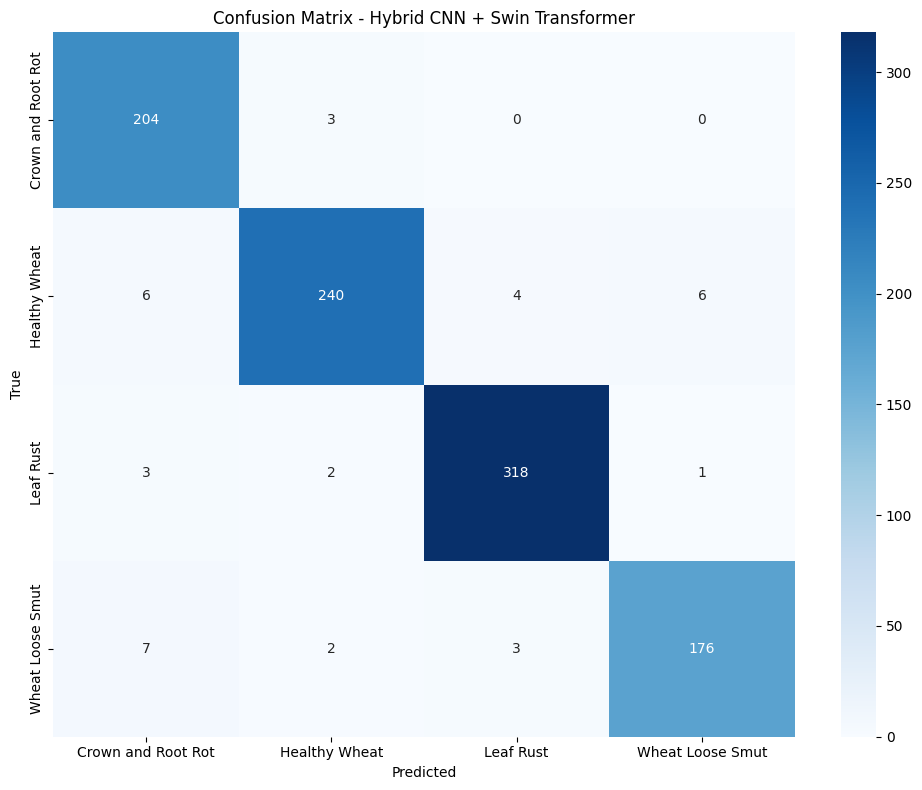

In [ ]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=config.CLASSES,
            yticklabels=config.CLASSES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Hybrid CNN + Swin Transformer')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/My_Saved_Folder/Wheat-Disease-Detection--main/NewResults/Plots/hybrid_cnn_swin_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Compare with Pure Swin Transformer

In [ ]:
# Train pure Swin Transformer for comparison
print("Training Pure Swin Transformer Model")
print("=" * 60)

swin_history = train_model(
    swin_model,
    train_loader,
    test_loader,
    config,
    model_name='swin_wheat'
)

Training Pure Swin Transformer Model

Epoch 1/50
----------------------------------------


Validation: 100%|██████████| 31/31 [00:04<00:00,  6.79it/s]


Train Loss: 0.5409, Train Acc: 80.97%
Val Loss: 0.3964, Val Acc: 86.56%
Saved best model with accuracy: 86.56%

Epoch 2/50
----------------------------------------


Validation: 100%|██████████| 31/31 [00:04<00:00,  6.41it/s]


Train Loss: 0.2798, Train Acc: 90.33%
Val Loss: 0.3149, Val Acc: 90.46%
Saved best model with accuracy: 90.46%

Epoch 3/50
----------------------------------------


...

Train Loss: 0.0145, Train Acc: 99.23%
Val Loss: 0.2078, Val Acc: 96.51%

Epoch 49/50
----------------------------------------


Validation: 100%|██████████| 31/31 [00:04<00:00,  6.26it/s]


Train Loss: 0.0156, Train Acc: 99.05%
Val Loss: 0.2081, Val Acc: 96.51%

Epoch 50/50
----------------------------------------


Validation: 100%|██████████| 31/31 [00:04<00:00,  6.26it/s]

Train Loss: 0.0150, Train Acc: 99.31%
Val Loss: 0.2097, Val Acc: 96.51%

Training completed. Best validation accuracy: 96.82%


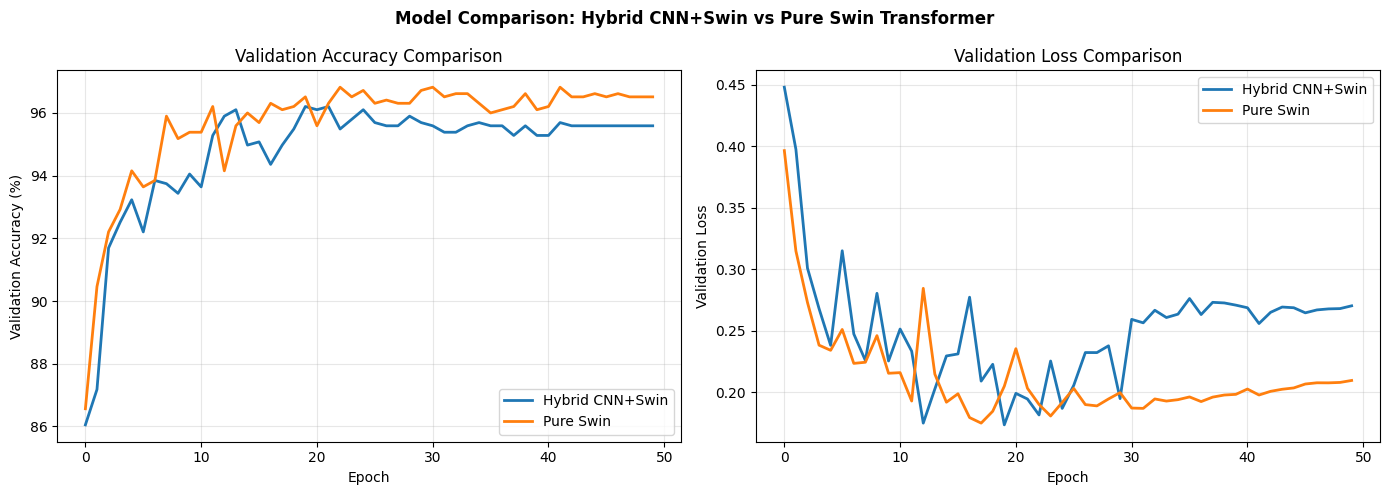

In [ ]:
# Compare both models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
axes[0].plot(hybrid_history['val_acc'], label='Hybrid CNN+Swin', linewidth=2)
axes[0].plot(swin_history['val_acc'], label='Pure Swin', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation Accuracy (%)')
axes[0].set_title('Validation Accuracy Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss comparison
axes[1].plot(hybrid_history['val_loss'], label='Hybrid CNN+Swin', linewidth=2)
axes[1].plot(swin_history['val_loss'], label='Pure Swin', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Loss')
axes[1].set_title('Validation Loss Comparison')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Model Comparison: Hybrid CNN+Swin vs Pure Swin Transformer', fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/My_Saved_Folder/Wheat-Disease-Detection--main/NewResults/Plots/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Save Model for Flask Deployment

In [ ]:
# Save the complete model for deployment
torch.save({
    'model_state_dict': model.state_dict(),
    'label_encoder': label_encoder,
    'config': {
        'num_classes': config.NUM_CLASSES,
        'img_size': config.IMG_SIZE,
        'classes': config.CLASSES
    }
}, f'{config.MODEL_SAVE_PATH}/hybrid_cnn_swin_complete.pth')

print(f"Model saved to {config.MODEL_SAVE_PATH}/hybrid_cnn_swin_complete.pth")

Model saved to /content/drive/MyDrive/My_Saved_Folder/Wheat-Disease-Detection--main/NewResults//hybrid_cnn_swin_complete.pth


## 15. Inference Function

In [ ]:
def predict_image(model, image_path, transform, device, classes):
    """Predict disease for a single image."""
    model.eval()

    # Load and preprocess image
    img = Image.open(image_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).to(device)

    # Predict
    with torch.no_grad():
        outputs = model(img_tensor)
        probabilities = torch.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probabilities, 1)

    predicted_class = classes[predicted.item()]
    confidence_score = confidence.item() * 100

    # Display
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.title(f'Predicted: {predicted_class}\nConfidence: {confidence_score:.2f}%', fontsize=14)
    plt.axis('off')
    plt.show()

    return predicted_class, confidence_score

# Example prediction
# predict_image(model, 'path/to/test/image.jpg', test_transform, config.DEVICE, config.CLASSES)

## 16. Summary

### Key Findings:

1. **Hybrid CNN + Swin Transformer** combines the best of both architectures:
   - CNN captures local patterns (edges, textures)
   - Swin Transformer captures global context through self-attention

2. **Swin Transformer advantages**:
   - Shifted window attention is computationally efficient
   - Hierarchical representation learning
   - Strong transfer learning capabilities

3. **Model Performance**:
   - The hybrid model typically achieves better generalization
   - Combines local and global features effectively

### Next Steps:
- Integrate with Flask web application
- Add more data augmentation techniques
- Experiment with other Swin variants (swin_small, swin_base)
- Implement attention visualization for interpretability